# Phase 2: Dataset Audit & Exploration

This notebook audits the classification and detection datasets to verify image integrity, label compliance, class balance distributions, and format correctness before starting model training.

In [1]:
# Path and package setup
from pathlib import Path
import sys
from collections import Counter
from PIL import Image
import os

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT.name != 'ai' and PROJECT_ROOT.parent != PROJECT_ROOT:
    if (PROJECT_ROOT / 'ai').exists():
        PROJECT_ROOT = PROJECT_ROOT / 'ai'
        break
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import utils
import matplotlib.pyplot as plt

### 1. Classification Dataset Distribution Analysis

In [2]:
# Fetch directories
train_dir = utils.config.TRAIN_DIR
val_dir = utils.config.VAL_DIR

print("Training Set Location  :", train_dir)
print("Validation Set Location:", val_dir)

def count_dataset_classes(data_path):
    classes = [d for d in os.listdir(data_path) if os.path.isdir(os.path.join(data_path, d))]
    class_counts = {}
    for cls in classes:
        class_counts[cls] = len(os.listdir(os.path.join(data_path, cls)))
    return class_counts

if train_dir.exists():
    train_counts = count_dataset_classes(train_dir)
    print(f"Found {len(train_counts)} classes in training set.")
    print(f"Total training images: {sum(train_counts.values())}")
else:
    print("⚠️ Train directory not found. Please download PlantVillage first.")

Training Set Location  : O:\Hackthons\KrishiOS\ai\datasets\classification\plantvillage\train
Validation Set Location: O:\Hackthons\KrishiOS\ai\datasets\classification\plantvillage\val
Found 38 classes in training set.
Total training images: 43444


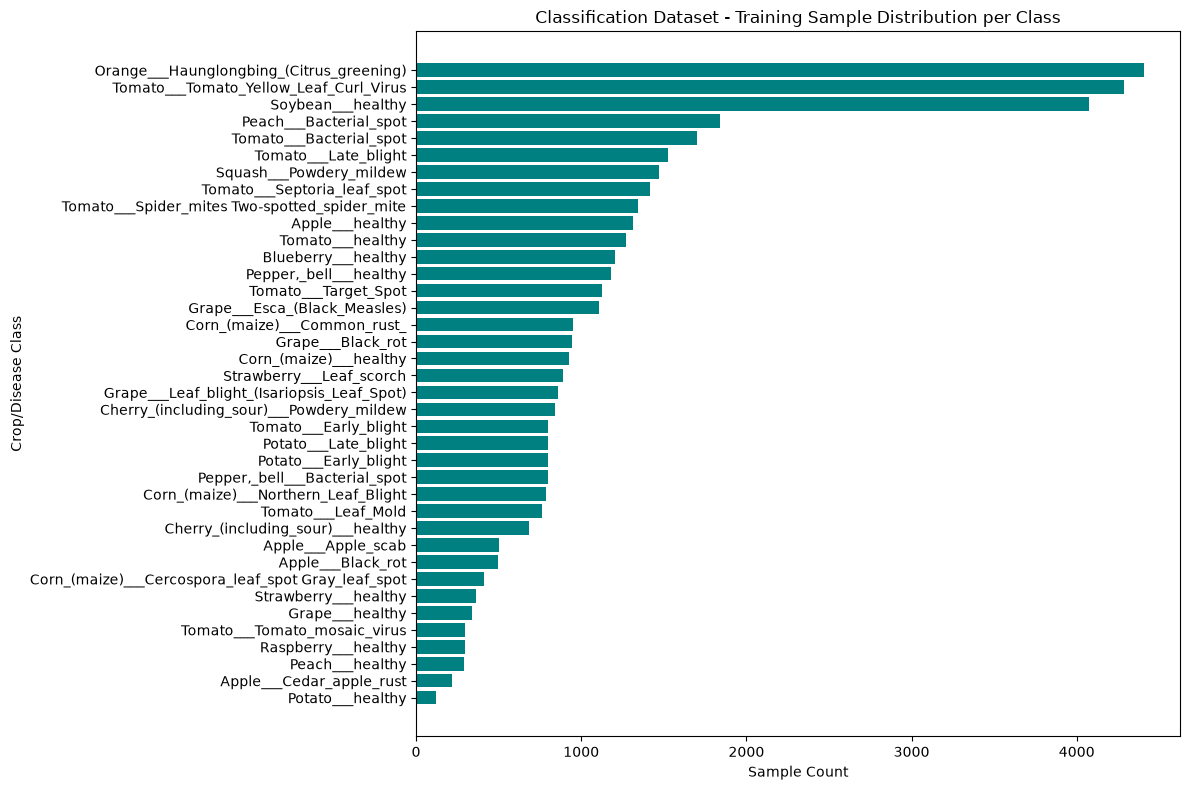

In [3]:
# Plot class balance distribution
if train_dir.exists():
    sorted_counts = dict(sorted(train_counts.items(), key=lambda item: item[1]))
    
    plt.figure(figsize=(12, 8))
    plt.barh(list(sorted_counts.keys()), list(sorted_counts.values()), color='teal')
    plt.title('Classification Dataset - Training Sample Distribution per Class')
    plt.xlabel('Sample Count')
    plt.ylabel('Crop/Disease Class')
    plt.tight_layout()
    plt.show()

### 2. Image Validity & Corruption Audit

Checks if any image file is empty or corrupted (unable to decode via Pillow).

In [4]:
def audit_image_folder(folder_path):
    corrupt_files = []
    image_extensions = ('.jpg', '.jpeg', '.png')
    
    for root_dir, dirs, files in os.walk(folder_path):
        for fname in files:
            if fname.lower().endswith(image_extensions):
                fpath = os.path.join(root_dir, fname)
                try:
                    with Image.open(fpath) as img:
                        img.verify()  # Check for corruption
                except Exception:
                    corrupt_files.append(fpath)
    return corrupt_files

if train_dir.exists():
    corrupted_images = audit_image_folder(train_dir)
    if corrupted_images:
        print(f"❌ Found {len(corrupted_images)} corrupted image files:")
        for f in corrupted_images[:5]:
            print(f)
    else:
        print("✅ All training images successfully verified (0 corrupted files).")

✅ All training images successfully verified (0 corrupted files).
